In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
#import pingouin as pg
import numpy as np

**Loading of data**


In [3]:
# Replace with our file path
df = pd.read_csv("ai_grading_final.csv")

# Required columns:
required_columns = [
    "answer_key_id",
    "true_mistakes",
    "prompt_type",
    "ai_estimated_mistakes"
]
print(df["ai_estimated_mistakes"])
# Dependent variable: AI grading error
df["ai_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]
df["Absolute_error"] = abs(df["ai_estimated_mistakes"]-df["true_mistakes"])
df["true_mistakes"] = df["true_mistakes"].astype("category")
df["prompt_type"] = df["prompt_type"].astype("category")

0       14
1       14
2       14
3       10
4       14
        ..
1992     0
1993     0
1994     0
1995     0
1996     0
Name: ai_estimated_mistakes, Length: 1997, dtype: int64


**2-way Mixed ANOVA**

Assumptions: Homogeneity of variance, Independence of observations, Normally-distributed dependent variable 

In [4]:
mixed_anova = pg.mixed_anova(
    data=df,
    dv="ai_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# 10. Q-Q plot of residual-like centered scores

df["cell_mean"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["ai_error"].transform("mean")

df["anova_residual"] = df["ai_error"] - df["cell_mean"]

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Mixed ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals vs condition means
#How far is this specific observation from the average result in the same condition? 
# One specific combination of true error level and prompt type.
#Condition means is the average value for each experimental condition.

plt.figure(figsize=(7, 5))
plt.scatter(df["cell_mean"], df["anova_residual"], alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Condition Means")
plt.xlabel("Condition mean")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("ai_error", "mean"),
        sd_ai_error=("ai_error", "std"),
        n=("ai_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'pg' is not defined

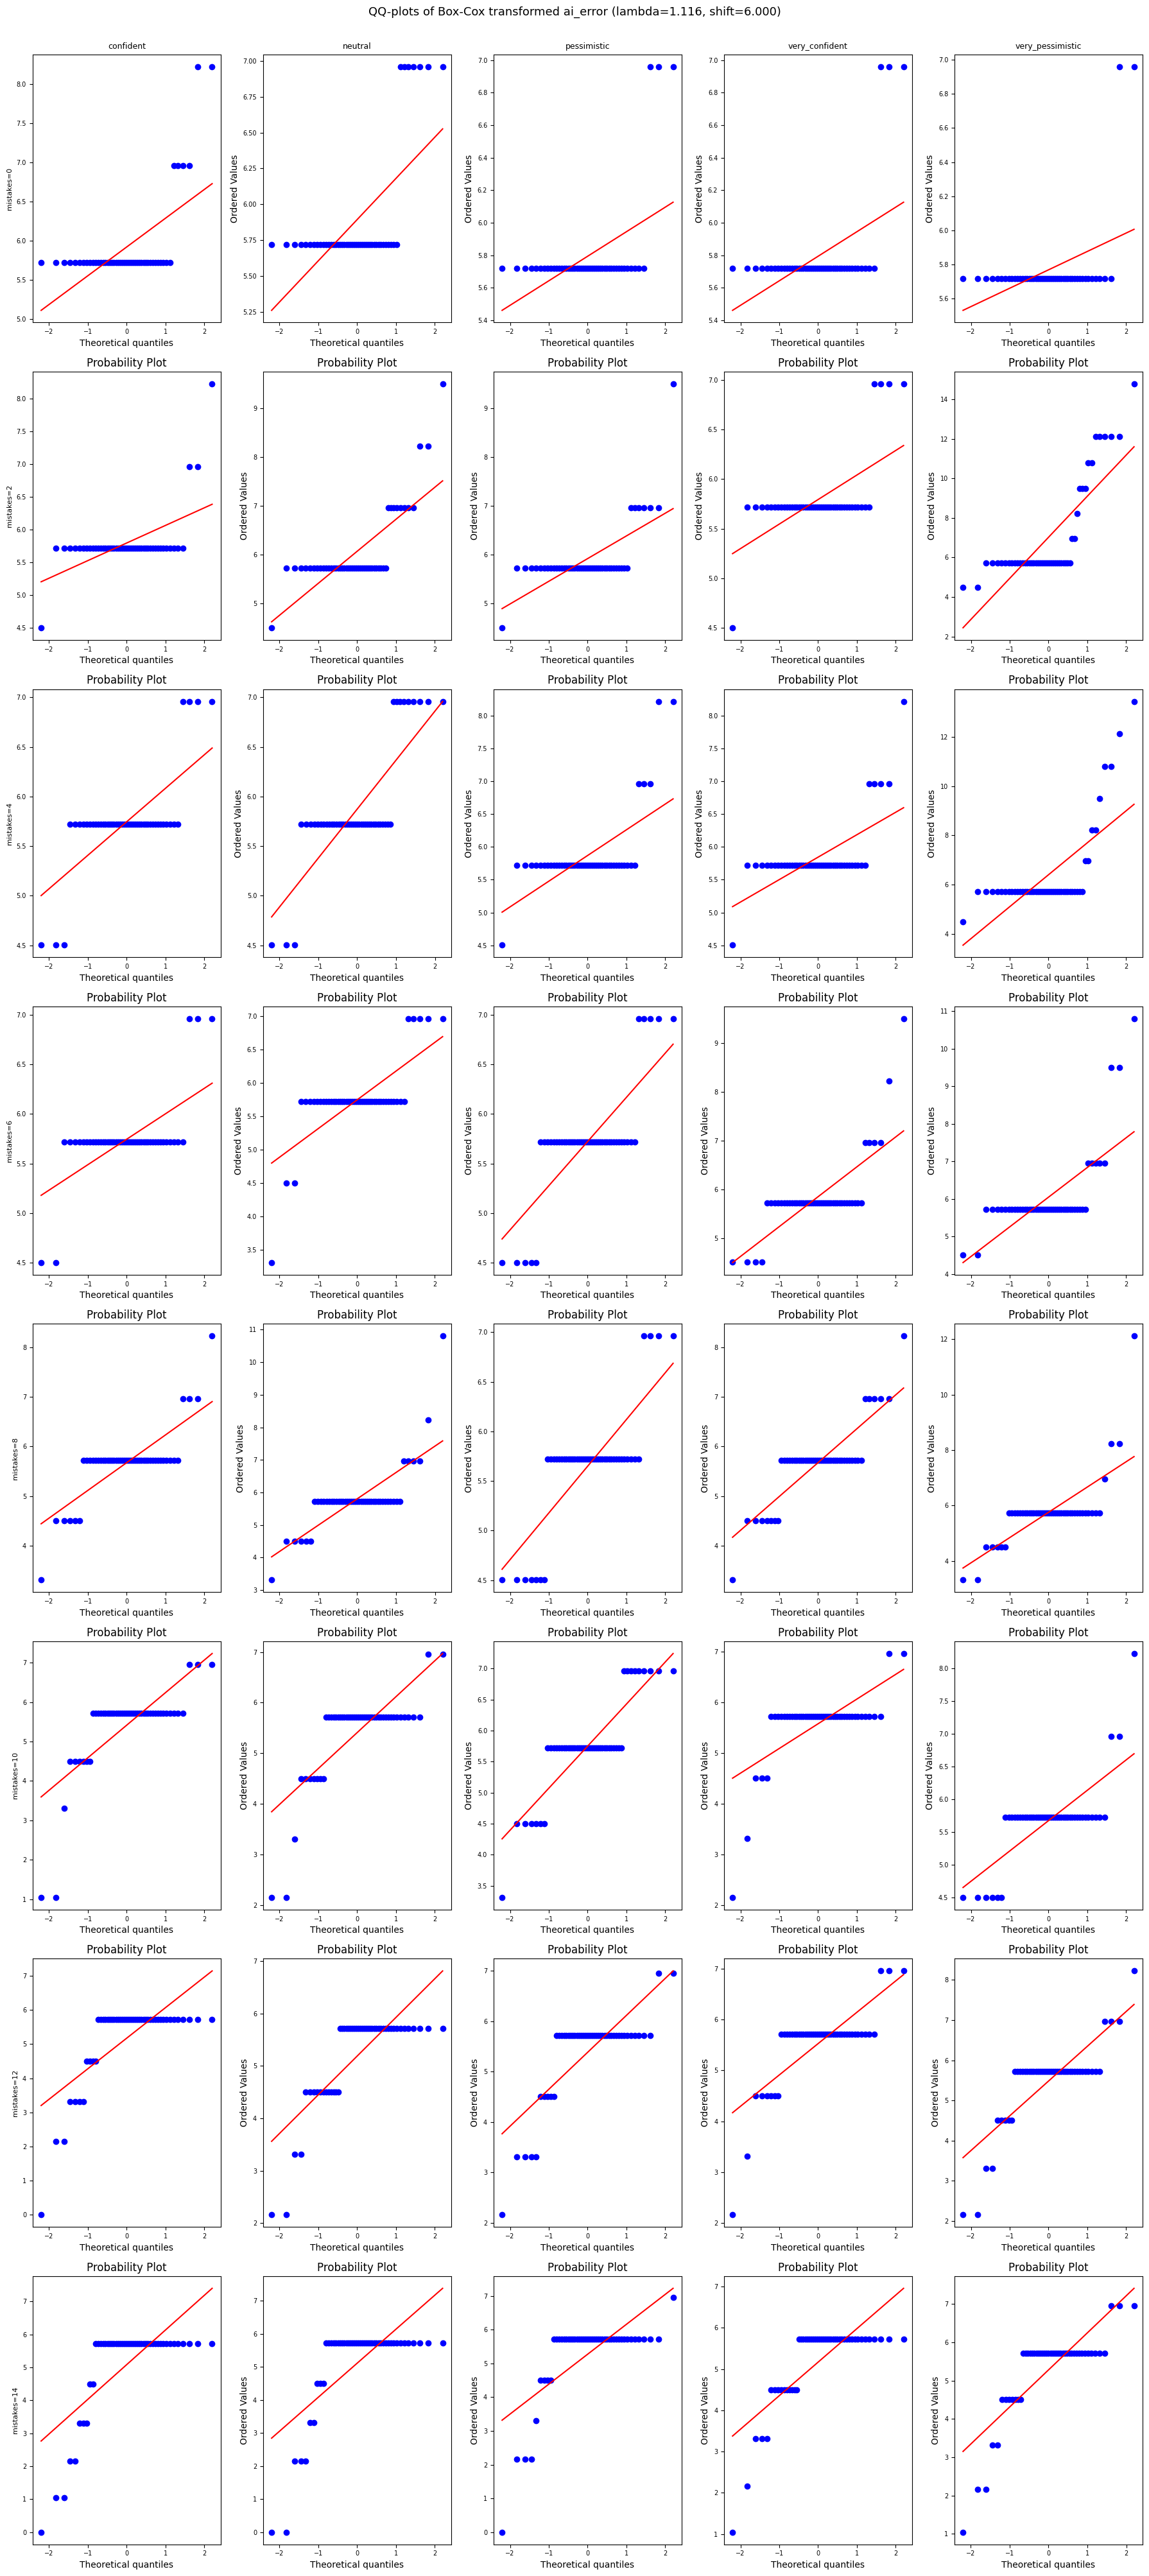

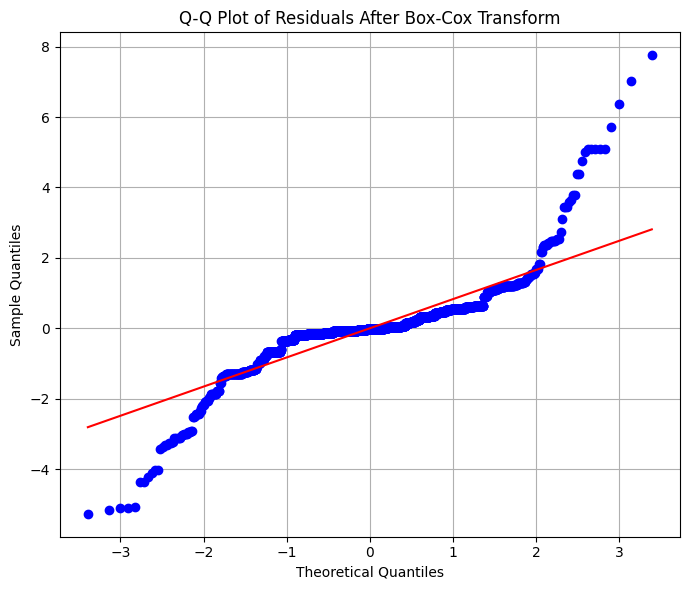

Box-Cox lambda: 1.115565
Global shift applied before Box-Cox: 6.000000


In [16]:
# qq plot matrix on Box-Cox transformed data
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Box-Cox must be applied to the response variable first.
# Since ai_error can be negative, shift it once globally before transforming.
raw = df["ai_error"].astype(float).to_numpy()
shift = 0.0
if raw.min() <= 0:
    shift = -raw.min() + 1

ai_error_bc, boxcox_lambda = stats.boxcox(raw + shift)
df["ai_error_boxcox"] = ai_error_bc

# Residuals are computed after the transformation.
df["cell_mean_boxcox"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["ai_error_boxcox"].transform("mean")
df["anova_residual_boxcox"] = df["ai_error_boxcox"] - df["cell_mean_boxcox"]

# Build the matrix from the transformed response.
matrix_bc = df.groupby(["true_mistakes", "prompt_type"])["ai_error_boxcox"].apply(np.array).unstack("prompt_type")

types = ["confident", "neutral", "pessimistic", "very_confident", "very_pessimistic"]
rows = matrix_bc.index.tolist()  # expected 16 true_mistakes levels

fig, axes = plt.subplots(len(rows), len(types), figsize=(18, 40), squeeze=False)

for r, tm in enumerate(rows):
    for c, prompt in enumerate(types):
        ax = axes[r, c]

        if prompt not in matrix_bc.columns:
            ax.set_visible(False)
            continue

        vals = matrix_bc.loc[tm, prompt]
        if not isinstance(vals, (np.ndarray, list, tuple)):
            ax.set_visible(False)
            continue

        vals = np.asarray(vals).ravel()
        if vals.size < 3:
            ax.set_visible(False)
            continue

        stats.probplot(vals, dist="norm", plot=ax)

        if r == 0:
            ax.set_title(prompt, fontsize=9)
        if c == 0:
            ax.set_ylabel(f"mistakes={tm}", fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle(f"QQ-plots of Box-Cox transformed ai_error (lambda={boxcox_lambda:.3f}, shift={shift:.3f})", y=1.002, fontsize=13)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual_boxcox"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals After Box-Cox Transform")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Box-Cox lambda: {boxcox_lambda:.6f}")
print(f"Global shift applied before Box-Cox: {shift:.6f}")

In [14]:
# Post-hoc tests between prompts
# Since prompt_type is a repeated-measures factor, comparisons between prompts should be paired t-tests with holm-correction.

posthoc_prompts = pg.pairwise_tests(
    data=df,
    dv="ai_error",
    within="prompt_type",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)

print(posthoc_prompts)


      Contrast                          A                        B  Paired  \
0  prompt_type  prompt_1_very_pessimistic     prompt_2_pessimistic    True   
1  prompt_type  prompt_1_very_pessimistic         prompt_3_neutral    True   
2  prompt_type  prompt_1_very_pessimistic       prompt_4_confident    True   
3  prompt_type  prompt_1_very_pessimistic  prompt_5_very_confident    True   
4  prompt_type       prompt_2_pessimistic         prompt_3_neutral    True   
5  prompt_type       prompt_2_pessimistic       prompt_4_confident    True   
6  prompt_type       prompt_2_pessimistic  prompt_5_very_confident    True   
7  prompt_type           prompt_3_neutral       prompt_4_confident    True   
8  prompt_type           prompt_3_neutral  prompt_5_very_confident    True   
9  prompt_type         prompt_4_confident  prompt_5_very_confident    True   

   Parametric          T    dof alternative         p_unc        p_corr  \
0        True   7.117956  479.0   two-sided  4.027446e-12  1.61097

**ABSOLUTE ERROR VERSION**

In [ ]:
import pingouin as pg

mixed_anova = pg.mixed_anova(
    data=df,
    dv="Absolute_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# 10. Q-Q plot of residual-like centered scores

df["cell_mean"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["Absolute_error"].transform("mean")

df["anova_residual"] = df["Absolute_error"] - df["cell_mean"]

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Mixed ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals vs condition means

plt.figure(figsize=(7, 5))
plt.scatter(df["cell_mean"], df["anova_residual"], alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Condition Means")
plt.xlabel("Condition mean")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("Absolute_error", "mean"),
        sd_ai_error=("Absolute_error", "std"),
        n=("Absolute_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Post-hoc tests between prompts
# Since prompt_type is a repeated-measures factor, comparisons between prompts should be paired t-tests with holm-correction.

posthoc_prompts = pg.pairwise_tests(
    data=df,
    dv="Absolute_error",
    within="prompt_type",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)

print(posthoc_prompts)


In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import patsy

# -----------------------------
# 1. Load and prepare data
# -----------------------------

df = pd.read_csv("Output_extraction/ai_grading_final.csv")

# Clean possible whitespace in IDs and prompt labels
df["answer_key_id"] = df["answer_key_id"].astype(str).str.strip()
df["prompt_type"] = df["prompt_type"].astype(str).str.strip()

# Create outcome variables
df["absolute_error"] = (df["ai_estimated_mistakes"] - df["true_mistakes"]).abs()
df["grading_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]

# Scale true_mistakes for better model fitting
df["true_mistakes_scaled"] = (
    df["true_mistakes"] - df["true_mistakes"].mean()
) / df["true_mistakes"].std()

# Encode answer_key_id as integer index for random effects
df["answer_key_idx"] = pd.Categorical(df["answer_key_id"]).codes

n_answer_keys = df["answer_key_idx"].nunique()

# -----------------------------
# 2. Design matrix for fixed effects
# -----------------------------
# This includes:
# - prompt_type
# - true_mistakes
# - prompt_type × true_mistakes interaction

formula = "1 + C(prompt_type) * true_mistakes_scaled"

X = patsy.dmatrix(formula, data=df, return_type="dataframe")

y = df["absolute_error"].astype(int).values
answer_key_idx = df["answer_key_idx"].values

coords = {
    "obs_id": np.arange(len(df)),
    "fixed_effect": X.columns,
    "answer_key": np.arange(n_answer_keys),
}

# -----------------------------
# 3. Zero-Inflated Negative Binomial GLMM
# -----------------------------

with pm.Model(coords=coords) as zinb_glmm:

    # Data containers
    X_data = pm.Data("X_data", X.values, dims=("obs_id", "fixed_effect"))
    answer_key_data = pm.Data("answer_key_data", answer_key_idx, dims="obs_id")

    # Fixed effects
    beta = pm.Normal("beta", mu=0, sigma=2, dims="fixed_effect")

    # Random intercept for answer_key_id
    sigma_answer_key = pm.HalfNormal("sigma_answer_key", sigma=1)

    answer_key_offset = pm.Normal(
        "answer_key_offset",
        mu=0,
        sigma=1,
        dims="answer_key"
    )

    answer_key_effect = pm.Deterministic(
        "answer_key_effect",
        answer_key_offset * sigma_answer_key,
        dims="answer_key"
    )

    # Linear predictor for the count part
    eta = (
        pm.math.dot(X_data, beta)
        + answer_key_effect[answer_key_data]
    )

    # Expected absolute error
    mu = pm.math.exp(eta)

    # Negative binomial dispersion parameter
    alpha = pm.HalfNormal("alpha", sigma=2)

    # Zero-inflation part
    # psi is the probability that an observation comes from the negative binomial process.
    # Lower psi means more extra zeros.
    zi_intercept = pm.Normal("zi_intercept", mu=0, sigma=2)
    psi = pm.math.sigmoid(zi_intercept)

    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial(
        "y_obs",
        psi=psi,
        mu=mu,
        alpha=alpha,
        observed=y,
        dims="obs_id"
    )

    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

# -----------------------------
# 4. Model summary
# -----------------------------

az.summary(
    trace,
    var_names=["beta", "sigma_answer_key", "alpha", "zi_intercept"],
    round_to=3
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sigma_answer_key, answer_key_offset, alpha, zi_intercept]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 32 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta[Intercept],-0.893,0.242,-1.325,-0.546,2551.483,2091.238,1.001,0.005,0.004
beta[C(prompt_type)[T.neutral]],0.208,0.179,-0.077,0.493,5178.529,6046.811,1.001,0.002,0.002
beta[C(prompt_type)[T.pessimistic]],-0.088,0.191,-0.399,0.217,5280.501,6157.005,1.001,0.003,0.002
beta[C(prompt_type)[T.very_confident]],-0.182,0.195,-0.490,0.130,5245.400,5452.107,1.001,0.003,0.002
beta[C(prompt_type)[T.very_pessimistic]],0.651,0.174,0.374,0.937,5426.744,6108.791,1.000,0.002,0.002
beta[true_mistakes_scaled],0.545,0.149,0.313,0.786,3551.357,4850.927,1.001,0.002,0.002
beta[C(prompt_type)[T.neutral]:true_mistakes_scaled],-0.276,0.185,-0.576,0.017,4617.154,5686.044,1.001,0.003,0.002
beta[C(prompt_type)[T.pessimistic]:true_mistakes_scaled],-0.134,0.200,-0.455,0.187,4645.335,5904.372,1.002,0.003,0.002
beta[C(prompt_type)[T.very_confident]:true_mistakes_scaled],-0.127,0.203,-0.450,0.200,4508.607,6075.595,1.001,0.003,0.002
beta[C(prompt_type)[T.very_pessimistic]:true_mistakes_scaled],-0.741,0.188,-1.047,-0.445,3958.897,5008.877,1.001,0.003,0.002


In [7]:
with zinb_glmm:
    idata_ppc = pm.sample_posterior_predictive(
        trace,
        extend_inferencedata=True,
        random_seed=42
    )

az.plot_ppc(idata_ppc)

Sampling: [y_obs]


Output()

/var/folders/17/zk5rsh150_n2c24m6gzdvb7m0000gn/T/ipykernel_8289/3383952096.py:2: UserWarning: groups {'posterior_predictive'} already exist in the DataTree and will be overwritten. To avoid this, set extend_inferencedata=False.
  idata_ppc = pm.sample_posterior_predictive(


AttributeError: module 'arviz' has no attribute 'plot_ppc'

In [4]:
summary = az.summary(trace, var_names=["beta"], round_to=3)
summary.index = X.columns
print(summary)

                                                     mean     sd  eti89_lb  \
Intercept                                          -0.893  0.242    -1.325   
C(prompt_type)[T.neutral]                           0.208  0.179    -0.077   
C(prompt_type)[T.pessimistic]                      -0.088  0.191    -0.399   
C(prompt_type)[T.very_confident]                   -0.182  0.195    -0.490   
C(prompt_type)[T.very_pessimistic]                  0.651  0.174     0.374   
true_mistakes_scaled                                0.545  0.149     0.313   
C(prompt_type)[T.neutral]:true_mistakes_scaled     -0.276  0.185    -0.576   
C(prompt_type)[T.pessimistic]:true_mistakes_scaled -0.134  0.200    -0.455   
C(prompt_type)[T.very_confident]:true_mistakes_... -0.127  0.203    -0.450   
C(prompt_type)[T.very_pessimistic]:true_mistake... -0.741  0.188    -1.047   

                                                    eti89_ub  ess_bulk  \
Intercept                                             -0.546  2551.